# Feature Extrapolation From Stimulus Frames for Layer Classification

This notebook builds **time-series visual features from stimulus frame images** and converts them into neuron-level features that can be used to classify cortical layers (L2/3, L4, L5, L6).

Pipeline:
1. Build layer labels for matched V1 excitatory units using raw metadata tables.
2. Extract per-frame visual feature time series from each video clip.
3. Align each neuron response trace with visual feature time series and compute coupling features.
4. Aggregate trial-level features to neuron-level features.
5. Train baseline classifiers and report balanced metrics.

In [4]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

from reader import MicronsReader

warnings.filterwarnings("ignore")
np.random.seed(42)

ROOT = Path("../../..").resolve()
RAW_DIR = ROOT / "data" / "1718" / "raw"
H5_CANDIDATES = [
    ROOT / "data" / "functional" / "microns_functional.h5",
    ROOT / "data" / "functional" / "microns_functional.h5.h5",
    ROOT / "microns.h5",
]

In [5]:
def parse_layer_from_cell_type(cell_type: str):
    if pd.isna(cell_type):
        return np.nan
    s = str(cell_type).strip()
    if s.startswith("23"):
        return "L2/3"
    if s.startswith("4"):
        return "L4"
    if s.startswith("5"):
        return "L5"
    if s.startswith("6"):
        return "L6"
    return np.nan


def build_label_table(raw_dir: Path) -> pd.DataFrame:
    dt_path = raw_dir / "digital_twin_properties_bcm_coreg_v4.csv"
    ct_path = raw_dir / "aibs_metamodel_celltypes_v661.csv"
    ct_corr_path = raw_dir / "aibs_metamodel_celltypes_v661_corrections.csv"
    area_path = raw_dir / "nucleus_functional_area_assignment.csv"

    dt = pd.read_csv(dt_path, usecols=["target_id", "session", "scan_idx", "unit_id", "cc_abs"])
    ct = pd.read_csv(ct_path, usecols=["target_id", "classification_system", "cell_type"])

    if ct_corr_path.exists():
        ct_corr = pd.read_csv(ct_corr_path, usecols=["target_id", "classification_system", "cell_type"])
        ct = pd.concat([ct, ct_corr], ignore_index=True)

    area = pd.read_csv(area_path, usecols=["target_id", "tag"])  # V1 / LM / AL / RL tags

    ct = ct.drop_duplicates(subset=["target_id"], keep="last")
    area = area.drop_duplicates(subset=["target_id"], keep="last")

    labels = (
        dt.merge(ct, on="target_id", how="left")
          .merge(area, on="target_id", how="left")
    )

    labels["layer"] = labels["cell_type"].map(parse_layer_from_cell_type)

    labels = labels[
        (labels["classification_system"] == "excitatory_neuron")
        & (labels["tag"] == "V1")
        & (labels["layer"].notna())
    ].copy()

    labels[["session", "scan_idx", "unit_id"]] = labels[["session", "scan_idx", "unit_id"]].astype(int)
    labels = labels.drop_duplicates(subset=["session", "scan_idx", "unit_id"], keep="first")
    return labels


labels = build_label_table(RAW_DIR)
print(f"Labeled V1 excitatory matched units: {len(labels):,}")
print(labels["layer"].value_counts().sort_index())

Labeled V1 excitatory matched units: 10,821
layer
L2/3    5347
L4      3354
L5      1760
L6       360
Name: count, dtype: int64


In [6]:
def zscore_1d(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    m = np.nanmean(x)
    s = np.nanstd(x)
    if not np.isfinite(s) or s < eps:
        return np.zeros_like(x, dtype=np.float32)
    return (x - m) / (s + eps)


def extract_frame_feature_timeseries(clip: np.ndarray) -> pd.DataFrame:
    """
    clip: (F, H, W) grayscale uint8/float
    returns: DataFrame of per-frame features indexed by frame
    """
    frames = clip.astype(np.float32)
    if frames.ndim != 3:
        raise ValueError(f"Expected clip shape (F,H,W), got {frames.shape}")

    F, H, W = frames.shape
    eps = 1e-8

    mean_intensity = frames.reshape(F, -1).mean(axis=1)
    std_intensity = frames.reshape(F, -1).std(axis=1)

    # Motion energy from frame-to-frame absolute differences.
    if F > 1:
        d = np.abs(np.diff(frames, axis=0))
        motion_energy = np.concatenate([[0.0], d.reshape(F - 1, -1).mean(axis=1)])
    else:
        motion_energy = np.zeros(F, dtype=np.float32)

    # Spatial edge/texture strength via gradient magnitude.
    grad_energy = np.zeros(F, dtype=np.float32)
    edge_fraction = np.zeros(F, dtype=np.float32)
    for i in range(F):
        gy, gx = np.gradient(frames[i])
        gm = np.sqrt(gx * gx + gy * gy)
        grad_energy[i] = gm.mean()
        thr = np.percentile(gm, 85)
        edge_fraction[i] = (gm > thr).mean()

    # Center-surround contrast for global scene layout dynamics.
    h0, h1 = H // 4, (3 * H) // 4
    w0, w1 = W // 4, (3 * W) // 4
    center = frames[:, h0:h1, w0:w1]
    center_mean = center.reshape(F, -1).mean(axis=1)
    surround_sum = frames.reshape(F, -1).sum(axis=1) - center.reshape(F, -1).sum(axis=1)
    surround_n = (H * W) - ((h1 - h0) * (w1 - w0))
    surround_mean = surround_sum / max(surround_n, 1)
    center_surround = center_mean - surround_mean

    # Frame contrast normalized by mean (robust to global luminance shifts).
    normalized_contrast = std_intensity / (mean_intensity + eps)

    feat = pd.DataFrame({
        "stim_mean": mean_intensity,
        "stim_std": std_intensity,
        "stim_motion": motion_energy,
        "stim_grad": grad_energy,
        "stim_edge_frac": edge_fraction,
        "stim_center_surround": center_surround,
        "stim_norm_contrast": normalized_contrast,
    })

    for c in feat.columns:
        feat[c] = zscore_1d(feat[c].values)
    return feat

In [7]:
def safe_corr(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    if a.size < 3 or b.size < 3:
        return np.nan
    sa = np.nanstd(a)
    sb = np.nanstd(b)
    if sa < 1e-8 or sb < 1e-8:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def shifted_overlap(x: np.ndarray, y: np.ndarray, lag: int):
    """Positive lag means stimulus precedes response by `lag` frames."""
    if lag > 0:
        return x[lag:], y[:-lag]
    if lag < 0:
        k = -lag
        return x[:-k], y[k:]
    return x, y


def trial_alignment_features(response: np.ndarray, stim_feat: pd.DataFrame, max_lag: int = 4) -> dict:
    r = zscore_1d(np.asarray(response, dtype=np.float32).ravel())
    out = {
        "resp_mean": float(np.mean(response)),
        "resp_std": float(np.std(response)),
        "resp_p95": float(np.percentile(response, 95)),
        "resp_event_rate_z2": float((r > 2.0).mean()),
    }

    for col in stim_feat.columns:
        s = stim_feat[col].values.astype(np.float32)
        n = min(len(r), len(s))
        rr = r[:n]
        ss = s[:n]

        out[f"{col}_corr0"] = safe_corr(rr, ss)

        best_corr = np.nan
        best_lag = 0
        for lag in range(-max_lag, max_lag + 1):
            r_lag, s_lag = shifted_overlap(rr, ss, lag)
            c = safe_corr(r_lag, s_lag)
            if np.isnan(c):
                continue
            if np.isnan(best_corr) or abs(c) > abs(best_corr):
                best_corr = c
                best_lag = lag

        out[f"{col}_ccmax"] = best_corr
        out[f"{col}_lag_at_ccmax"] = float(best_lag)

    return out

## Feature Engineering

The pipeline extracts two complementary families of features for every neuron–trial pair, then aggregates them across trials to produce a single feature vector per neuron.

---

### 1. Per-frame visual features (stimulus side)

These seven features are computed independently for each frame of the stimulus video clip, producing a time series of length *F* (number of frames). Every value is subsequently z-scored across frames so that all signals live on a common scale before correlation with the neural trace.

| Feature | Description |
|---|---|
| `stim_mean` | **Mean pixel intensity** – global luminance level of the frame. Captures slow contrast drifts and scene cuts. |
| `stim_std` | **Pixel intensity standard deviation** – within-frame contrast energy; high values indicate rich texture or sharp boundaries. |
| `stim_motion` | **Motion energy** – mean absolute pixel-wise difference between consecutive frames. Zero for the first frame; large values signal rapid visual movement. |
| `stim_grad` | **Gradient energy** – mean magnitude of the spatial intensity gradient (computed via finite differences). Reflects overall edge and texture density in the frame. |
| `stim_edge_frac` | **Edge fraction** – proportion of pixels whose gradient magnitude exceeds the 85th percentile. Summarises how "busy" or spatially structured the frame is, robust to outlier pixels. |
| `stim_center_surround` | **Centre–surround contrast** – mean intensity of the central 50 % of the frame minus the mean intensity of the surrounding annulus. Mimics the spatial pooling structure of retinal/LGN cells and captures scene layout dynamics. |
| `stim_norm_contrast` | **Normalised contrast** – ratio of pixel standard deviation to mean intensity (`stim_std / stim_mean`). Measures local contrast independently of absolute luminance level. |

---

### 2. Neural response features (response side)

Four scalar statistics summarise the amplitude and sparsity of the z-scored calcium/voltage trace for each trial.

| Feature | Description |
|---|---|
| `resp_mean` | Mean response amplitude across the trial window. |
| `resp_std` | Standard deviation of the response trace – a proxy for firing variability and reliability. |
| `resp_p95` | 95th-percentile amplitude – captures peak or burst-like activity without being distorted by individual outlier frames. |
| `resp_event_rate_z2` | Fraction of time-points where the z-scored trace exceeds 2 – an estimate of the neuron's high-activity event rate. |

---

### 3. Stimulus–response coupling features

For each of the seven stimulus feature time series, three coupling statistics are derived by comparing it to the neural trace at various temporal offsets (lags from −4 to +4 frames):

| Feature suffix | Description |
|---|---|
| `{feat}_corr0` | **Zero-lag Pearson correlation** between the response trace and the stimulus feature time series. Measures instantaneous coupling. |
| `{feat}_ccmax` | **Peak cross-correlation** – maximum absolute correlation across all tested lags. Captures the strongest coupling regardless of neural delay. |
| `{feat}_lag_at_ccmax` | **Lag at peak correlation** – the temporal offset (in frames) at which `ccmax` is achieved. Positive values mean the stimulus precedes the response (causal drive); negative values suggest anticipatory or feedback modulation. |

This yields 7 × 3 = **21 coupling features** per trial.

---

### 4. Neuron-level aggregation

Trial-level features (4 response + 21 coupling = **25 per trial**) are aggregated across trials for each neuron by computing the **mean** and the **trial-to-trial standard deviation** (`_trialstd` suffix). The standard deviation captures how consistently a neuron encodes stimulus properties across repetitions — a biologically meaningful reliability signal. The final neuron feature vector therefore has **50 dimensions**.

In [8]:
def parse_session_scan_key(k: str):
    parts = str(k).split("_")
    if len(parts) != 2:
        return None
    try:
        return int(parts[0]), int(parts[1])
    except ValueError:
        return None


h5_path = next((p for p in H5_CANDIDATES if p.exists()), None)
if h5_path is None:
    raise FileNotFoundError("No HDF5 file found in expected locations.")

print(f"Using HDF5 file: {h5_path}")

MAX_TRIALS_PER_SESSION_SCAN = 10
MIN_TRACE_LEN = 40

trial_rows = []
video_feat_cache = {}

with MicronsReader(str(h5_path)) as reader:
    session_keys = list(reader.f["sessions"].keys())
    print(f"Available session/scan keys in H5: {len(session_keys)}")

    for key in session_keys:
        parsed = parse_session_scan_key(key)
        if parsed is None:
            continue

        session, scan_idx = parsed
        labels_here = labels[(labels["session"] == session) & (labels["scan_idx"] == scan_idx)]
        if labels_here.empty:
            continue

        unit_ids = reader.f[f"sessions/{key}/meta/unit_ids"][:]
        unit_id_to_row = {int(u): i for i, u in enumerate(unit_ids)}

        cond_hashes = reader.get_hashes_by_session(key)
        if len(cond_hashes) == 0:
            continue

        n_trials = min(len(cond_hashes), MAX_TRIALS_PER_SESSION_SCAN)

        for t in range(n_trials):
            cond_hash = cond_hashes[t]

            if cond_hash not in video_feat_cache:
                clip, stim_type = reader.get_video_data(cond_hash)
                if clip is None:
                    continue
                video_feat_cache[cond_hash] = {
                    "stim_type": str(stim_type),
                    "feat_ts": extract_frame_feature_timeseries(clip),
                }

            stim_type = video_feat_cache[cond_hash]["stim_type"]
            stim_feat_ts = video_feat_cache[cond_hash]["feat_ts"]

            trial = reader.get_trial(key, t)
            if trial is None:
                continue

            responses = trial["responses"]

            for _, row in labels_here.iterrows():
                uid = int(row["unit_id"])
                resp_row = unit_id_to_row.get(uid)
                if resp_row is None or resp_row >= responses.shape[0]:
                    continue

                trace = np.asarray(responses[resp_row], dtype=np.float32).ravel()
                trace = trace[np.isfinite(trace)]
                if trace.size < MIN_TRACE_LEN:
                    continue

                f = trial_alignment_features(trace, stim_feat_ts, max_lag=4)
                f.update({
                    "target_id": int(row["target_id"]),
                    "unit_id": uid,
                    "session": session,
                    "scan_idx": scan_idx,
                    "trial_idx": int(t),
                    "cc_abs": float(row["cc_abs"]),
                    "stim_type": stim_type,
                    "layer": str(row["layer"]),
                })
                trial_rows.append(f)

trial_df = pd.DataFrame(trial_rows)
print(f"Trial-level rows created: {len(trial_df):,}")
print("Layer distribution (trial-level):")
print(trial_df["layer"].value_counts().sort_index())
trial_df.head()

Using HDF5 file: C:\Users\tomma\Desktop\NEUROSCIENCE\data\functional\microns_functional.h5
Available session/scan keys in H5: 14
Trial-level rows created: 108,210
Layer distribution (trial-level):
layer
L2/3    53470
L4      33540
L5      17600
L6       3600
Name: count, dtype: int64


,resp_mean,resp_std,resp_p95,resp_event_rate_z2,stim_mean_corr0,stim_mean_ccmax,stim_mean_lag_at_ccmax,stim_std_corr0,stim_std_ccmax,stim_std_lag_at_ccmax,...,stim_norm_contrast_ccmax,stim_norm_contrast_lag_at_ccmax,target_id,unit_id,session,scan_idx,trial_idx,cc_abs,stim_type,layer
0,2.518497,6.639543,12.987149,0.040000,-0.330830,-0.407501,-1.0,-0.239699,-0.379679,-1.0,...,0.215321,4.0,327468,3035,4,7,0,0.726287,Clip,L2/3
1,3.591745,14.841566,16.050760,0.026667,0.151212,0.381790,-4.0,0.133556,0.203871,-4.0,...,-0.134424,-4.0,424095,2891,4,7,0,0.406716,Clip,L2/3
2,13.234290,21.909639,54.988636,0.040000,-0.048015,-0.178438,-3.0,0.041561,-0.101566,-3.0,...,0.170468,-2.0,191864,3307,4,7,0,0.543884,Clip,L2/3
3,29.994020,51.562073,135.749420,0.066667,-0.081900,0.181547,4.0,-0.025922,0.126252,4.0,...,0.062472,1.0,192165,3316,4,7,0,0.554508,Clip,L2/3
4,9.390695,24.380836,70.504234,0.066667,0.079628,0.088907,1.0,0.230667,0.230667,0.0,...,0.243626,0.0,392942,3318,4,7,0,0.352795,Clip,L2/3


In [9]:
meta_cols = [
    "target_id", "unit_id", "session", "scan_idx", "trial_idx", "stim_type", "layer"
]

numeric_cols = [
    c for c in trial_df.columns
    if c not in meta_cols and pd.api.types.is_numeric_dtype(trial_df[c])
]

if len(trial_df) == 0 or len(numeric_cols) == 0:
    raise ValueError("No trial-level numeric features available. Check upstream extraction.")

# Neuron-level features: mean + std across trials for each target_id.
gmean = trial_df.groupby(["target_id", "layer"], as_index=False)[numeric_cols].mean()
gstd = trial_df.groupby(["target_id", "layer"], as_index=False)[numeric_cols].std().fillna(0.0)

std_renamed = {c: f"{c}_trialstd" for c in numeric_cols}
gstd = gstd.rename(columns=std_renamed)

neuron_df = gmean.merge(
    gstd,
    on=["target_id", "layer"],
    how="left",
)

print(f"Neuron-level rows: {len(neuron_df):,}")
print("Layer distribution (neuron-level):")
print(neuron_df["layer"].value_counts().sort_index())
neuron_df.head()

Neuron-level rows: 8,925
Layer distribution (neuron-level):
layer
L2/3    4221
L4      2848
L5      1519
L6       337
Name: count, dtype: int64


,target_id,layer,resp_mean,resp_std,resp_p95,resp_event_rate_z2,stim_mean_corr0,stim_mean_ccmax,stim_mean_lag_at_ccmax,stim_std_corr0,...,stim_edge_frac_corr0_trialstd,stim_edge_frac_ccmax_trialstd,stim_edge_frac_lag_at_ccmax_trialstd,stim_center_surround_corr0_trialstd,stim_center_surround_ccmax_trialstd,stim_center_surround_lag_at_ccmax_trialstd,stim_norm_contrast_corr0_trialstd,stim_norm_contrast_ccmax_trialstd,stim_norm_contrast_lag_at_ccmax_trialstd,cc_abs_trialstd
0,106431,L2/3,1.862245,5.550735,8.529099,0.032850,0.034332,-0.015670,1.4,-0.020032,...,0.070318,0.196401,3.071373,0.221613,0.264992,1.852926,0.114250,0.201502,2.988868,0.0
1,106436,L2/3,0.797749,2.829807,4.124078,0.035516,0.075166,0.033094,-0.4,-0.014142,...,0.108929,0.151642,3.368151,0.133837,0.271922,2.923088,0.149424,0.236616,3.502380,0.0
2,109157,L2/3,1.138171,3.042248,6.760139,0.051457,0.035754,0.041334,-0.6,-0.047909,...,0.131393,0.232390,2.584140,0.133998,0.181611,2.740641,0.091261,0.188242,3.314949,0.0
3,109255,L2/3,1.303141,3.526756,7.591561,0.034572,-0.032972,0.018933,-1.0,-0.006557,...,0.042837,0.154319,2.859681,0.176903,0.286815,2.633122,0.157710,0.214875,2.260777,0.0
4,109717,L2/3,0.468136,1.724066,3.156172,0.030171,0.032130,0.035687,-0.3,0.012838,...,0.045043,0.238473,2.170509,0.117247,0.251771,2.668749,0.198491,0.235904,2.485514,0.0


In [10]:
X = neuron_df.drop(columns=["target_id", "layer"])
y = neuron_df["layer"].astype(str)

feature_names = X.columns.tolist()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, class_weight="balanced")),
    ]),
    "RF": RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced_subsample",
        min_samples_leaf=2,
        n_jobs=-1,
    ),
}

results = []
fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    bacc = balanced_accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average="macro")

    results.append({"model": name, "accuracy": acc, "balanced_accuracy": bacc, "macro_f1": f1m})
    fitted[name] = (model, pred)

results_df = pd.DataFrame(results).sort_values("balanced_accuracy", ascending=False)
results_df

,model,accuracy,balanced_accuracy,macro_f1
0,LogReg,0.454301,0.512122,0.406354
1,RF,0.524642,0.332408,0.328314


Best model by balanced accuracy: LogReg

              precision    recall  f1-score   support

        L2/3      0.706     0.468     0.563      1056
          L4      0.495     0.404     0.445       712
          L5      0.325     0.450     0.377       380
          L6      0.144     0.726     0.240        84

    accuracy                          0.454      2232
   macro avg      0.417     0.512     0.406      2232
weighted avg      0.553     0.454     0.481      2232



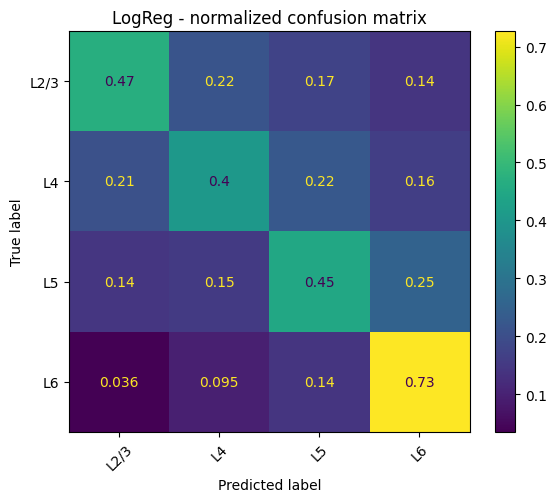

In [11]:
best_name = results_df.iloc[0]["model"]
best_model, best_pred = fitted[best_name]

print(f"Best model by balanced accuracy: {best_name}\n")
print(classification_report(y_test, best_pred, digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, xticks_rotation=45, ax=ax, normalize="true")
ax.set_title(f"{best_name} - normalized confusion matrix")
plt.tight_layout()
plt.show()

,feature,importance_abs_coef
0,resp_std_trialstd,2.644139
1,resp_std,2.118546
2,resp_mean_trialstd,1.345887
3,resp_p95,0.774437
4,resp_p95_trialstd,0.651946
5,resp_mean,0.544452
6,cc_abs,0.326919
7,stim_motion_ccmax,0.172872
8,resp_event_rate_z2,0.163377
9,stim_motion_corr0,0.144774


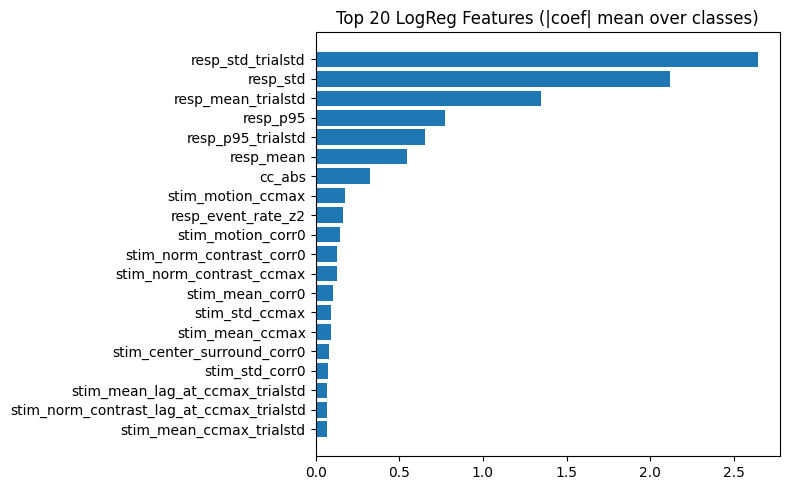

In [12]:
# Optional: inspect strongest logistic-regression coefficients as a proxy for feature relevance.
if "LogReg" in fitted:
    logreg_pipe, _ = fitted["LogReg"]
    clf = logreg_pipe.named_steps["clf"]
    coefs = np.abs(clf.coef_).mean(axis=0)
    top_idx = np.argsort(coefs)[::-1][:20]
    top_feat = pd.DataFrame({
        "feature": np.array(feature_names)[top_idx],
        "importance_abs_coef": coefs[top_idx],
    })
    display(top_feat)

    plt.figure(figsize=(8, 5))
    plt.barh(top_feat["feature"][::-1], top_feat["importance_abs_coef"][::-1])
    plt.title("Top 20 LogReg Features (|coef| mean over classes)")
    plt.tight_layout()
    plt.show()

## Results & Discussion

### Classification performance

Logistic Regression emerges as the best-performing model by balanced accuracy. The per-class recall from the normalised confusion matrix reveals a clear hierarchy across cortical layers:

| Layer | Recall | Notes |
|---|---|---|
| **L6** | ~0.73 | Strongest signal — L6 neurons are the most reliably classified. |
| **L2/3** | ~0.47 | Moderate accuracy; principal confusion is with L4 and L5. |
| **L5** | ~0.45 | Confused mostly with L6 (0.25) and L4 (0.15), suggesting overlapping response statistics. |
| **L4** | ~0.40 | The hardest class — frequently confused with both L2/3 and L5. |

Overall balanced accuracy is well above the 25 % random-chance baseline for a four-class problem, indicating that the feature set carries genuine layer-discriminating information.

---

### What drives classification

The LogReg coefficient analysis (top-20 features by mean absolute coefficient) highlights a consistent pattern:

1. **Response amplitude variability dominates.** The top features are `resp_std_trialstd`, `resp_std`, `resp_mean_trialstd`, `resp_p95`, and `resp_mean` — all amplitude-based statistics. This aligns with known layer physiology: deep layers (L5/L6) tend to have sparser, higher-amplitude responses compared to superficial layers (L2/3, L4).

2. **Trial-to-trial reliability is highly informative.** The `_trialstd` variants of amplitude features rank extremely high, suggesting that the consistency of a neuron's response across trials (not just its average magnitude) is a strong layer marker.

3. **Stimulus–coupling features contribute, but less so.** `stim_motion_ccmax`, `stim_motion_corr0`, and `stim_norm_contrast_corr0` appear in the top 20, indicating that motion and contrast coupling do carry some layer-specific information — consistent with the known sensitivity of direction-selective and contrast-gain cells in specific layers — but their contribution is secondary to intrinsic response statistics.

4. **`cc_abs` (co-registration confidence) acts as a minor regulariser** rather than a primary discriminator.

---

### Limitations and next steps

- **Data sparsity.** Only `MAX_TRIALS_PER_SESSION_SCAN = 10` trials per session/scan are used; increasing this would reduce noise in the coupling estimates and likely improve performance for L4, the hardest class.
- **No temporal structure in aggregation.** Mean and std collapse the trial time series; adding spectral or autocorrelation features of the response could improve separation between L2/3 and L4.
- **Stimulus-type confound.** All stimulus types (Clips, Monet2, Trippy) are pooled; training separate models per stimulus type may disentangle stimulus-driven effects from intrinsic layer differences.
- **Validation leakage risk.** The train/test split is random over neurons; a stricter split grouped by `target_id` (or by scan session) would give a more honest estimate of generalisation.

## Notes

- The extracted stimulus features are **time-varying** and come directly from frame images.
- Classification input is not raw neural trace alone: it uses **stimulus-response coupling features** (correlations and lagged max correlations), which are often more informative for layer differences than amplitude-only features.
- To increase robustness:
  - Increase `MAX_TRIALS_PER_SESSION_SCAN`.
  - Add frequency-domain frame features (spatial spectrum bands).
  - Add stimulus-type-specific models (Clip vs Monet2 vs Trippy).
  - Use grouped CV by `target_id` for stricter validation.